## Energy Balance Model of the Earth's Climate(Roberto Castro Molinares)

One of the simplest ways to understand the evolution of the Earth's climate is to consider the balance between the energy received from the Sun and the energy emitted back to space.

This type of approach is known as an **Energy Balance Model (EBM)** and represents one of the most fundamental models used in climate science.

---

## Earth's Energy Budget

<figure style="text-align: center;">
  <img src="https://github.com/carlospi2000/computational_modelling_geosciences/blob/main/04.modelling/energy_budget.png?raw=1" width="500">
  <figcaption>
  <b>Figure 1.</b> Earth's energy budget showing incoming solar radiation and outgoing infrared radiation.
  </figcaption>
</figure>

The Earth's climate system receives energy from the Sun and loses energy by emitting infrared radiation to space. The evolution of the global temperature can therefore be described using the principle of **energy conservation**:

$$
\text{Rate of energy change} = \text{Energy in} - \text{Energy out}
$$

---

## Incoming Solar Radiation

The Earth receives energy from the Sun at a rate known as the **solar constant**:

$$
S \approx 1361 \; W\,m^{-2}
$$

Because the Earth is spherical, this radiation must be averaged over the entire planetary surface. This introduces a geometric factor of $\frac{1}{4}$:

$$
\frac{S}{4}
$$

However, not all solar radiation is absorbed. A fraction of it is reflected by clouds, ice, and atmospheric particles. This fraction is called the **planetary albedo**, denoted by $\alpha$.

The absorbed solar radiation therefore becomes

$$
(1-\alpha)\frac{S}{4}
$$

For the present Earth the global average albedo is approximately

$$
\alpha \approx 0.3
$$

---

## Outgoing Infrared Radiation

The Earth emits thermal radiation to space approximately according to the **Stefan–Boltzmann law**:

$$
F = \sigma T^4
$$

where

- $\sigma$ is the Stefan–Boltzmann constant

$$
\sigma = 5.67 \times 10^{-8} \; W\,m^{-2}\,K^{-4}
$$

Because greenhouse gases partially absorb infrared radiation, we introduce an efficiency factor $\epsilon$ that represents the effect of the atmosphere on outgoing radiation. The outgoing radiation can therefore be written as

$$
\epsilon \sigma T^4
$$

---

## Climate Energy Balance Equation

Using the conservation of energy, the rate of change of the Earth's thermal energy can be written as

$$
C \frac{dT}{dt} =
(1-\alpha)\frac{S}{4}
-
\epsilon\sigma T^4
$$

where

- $T$ = global mean temperature (K)
- $C$ = effective heat capacity of the climate system
- $S$ = solar constant
- $\alpha$ = planetary albedo
- $\sigma$ = Stefan–Boltzmann constant
- $\epsilon$ = radiative efficiency of the atmosphere

The first term represents **solar heating**, while the second term represents **infrared cooling** of the planet.

When these two terms are equal, the system is in **radiative equilibrium**:

$$
\frac{dT}{dt}=0
$$

---

## Ice–Albedo Feedback

In the simple model above the albedo is assumed to be constant. In reality, however, the albedo depends strongly on the temperature of the planet.

When the temperature decreases:

- ice and snow coverage increase
- the planetary albedo increases
- more solar radiation is reflected

This produces additional cooling. This mechanism is known as the **ice–albedo feedback**.

To represent this effect, the albedo can be modeled as a function of temperature:

$$
\alpha(T)
$$

A simple parameterization is

$$
\alpha(T) =
\begin{cases}
0.6 & T < 260\,K \\
0.3 & T > 280\,K
\end{cases}
$$

with a smooth transition between these two regimes.

---

## Climate Model with Ice–Albedo Feedback

Including this temperature dependence leads to the final model used in this exercise:

$$
C \frac{dT}{dt} =
(1-\alpha(T))\frac{S}{4}
-
\epsilon\sigma T^4
$$

This nonlinear differential equation describes the evolution of the global mean temperature of the planet.

---

## Multiple Climate States

When the albedo depends on temperature, the system can exhibit **multiple equilibrium states**:

- a **warm climate state** with low ice coverage and low albedo
- a **cold climate state** with extensive ice coverage and high albedo

In extreme cases the model predicts a state known as **Snowball Earth**, where much of the planet becomes covered by ice.

Although highly simplified, this model captures important mechanisms controlling the stability of the Earth's climate.

# Estimating the Earth's Radiative Equilibrium Temperature

Before solving the climate model numerically, we can estimate the temperature that the Earth would have if the incoming and outgoing radiation were exactly balanced.

At equilibrium the temperature does not change with time:

$$
\frac{dT}{dt}=0
$$

The energy balance equation therefore becomes

$$
(1-\alpha)\frac{S}{4} = \epsilon \sigma T^4
$$

For a simple estimate we assume

- $\epsilon = 1$ (the Earth radiates as a perfect blackbody)
- planetary albedo $\alpha = 0.3$
- solar constant $S = 1361 \, W\,m^{-2}$

---

## Absorbed Solar Radiation

The absorbed solar radiation is

$$
(1-\alpha)\frac{S}{4}
$$

Substituting the values:

$$
(1-0.3)\frac{1361}{4}
$$

$$
= 0.7 \times 340.25
$$

$$
\approx 238 \, W\,m^{-2}
$$

This value corresponds closely to the **observed outgoing radiation in the Earth's energy budget**.

---

## Solving for the Equilibrium Temperature

Setting absorbed and emitted radiation equal:

$$
\sigma T^4 = 238
$$

Using

$$
\sigma = 5.67\times10^{-8} \, W\,m^{-2}\,K^{-4}
$$

we obtain

$$
T = \left(\frac{238}{\sigma}\right)^{1/4}
$$

which gives

$$
T \approx 255\,K
$$

---

## Comparison with the Real Earth

The observed global mean surface temperature of the Earth is approximately

$$
T_{Earth} \approx 288\,K
$$

or

$$
15^\circ C
$$

This means that the real Earth is about

$$
33\,K
$$

warmer than the simple radiative equilibrium temperature.

---

## Role of the Greenhouse Effect

This difference is caused by the **greenhouse effect**.

Greenhouse gases such as

- water vapor
- carbon dioxide
- methane

absorb and re-emit infrared radiation, trapping part of the outgoing heat and warming the surface of the planet.

In the Energy Balance Model this effect is represented by the parameter

$$
\epsilon
$$

which reduces the efficiency with which the Earth loses energy to space.

---

## Why This Matters for the Model

The simple calculation above illustrates two key ideas:

1. The Earth's temperature is determined by a balance between **solar heating** and **infrared cooling**.

2. Small changes in parameters such as **albedo** or **greenhouse forcing** can shift this balance and lead to climate change.

In the following sections we will use numerical methods to simulate how the global temperature evolves over time using the **Energy Balance Model**.

# Model 1: Earth's Temperature at Constant Albedo

In [1]:
# Define physical constants

import numpy as np
import matplotlib.pyplot as plt

# Physical constants

S = 1361             # Solar constant (W/m^2)
sigma = 5.67e-8      # Stefan-Boltzmann constant
alpha = 0.3          # Planetary albedo
epsilon = 1.0        # Radiative efficiency

C = 4e8              # Effective heat capacity (J m^-2 K^-1)

In [3]:
# Define a function containing the differential equation

def dTdt(T):

    incoming = S * (1 - alpha) / 4
    outgoing = epsilon * sigma * T**4

    return (incoming - outgoing) / C

In [5]:
def rk4_step(T, dt):

    k1 = dTdt(T)

    k2 = dTdt(T + 0.5*dt*k1)

    k3 = dTdt(T + 0.5*dt*k2)

    k4 = dTdt(T + dt*k3)

    return T + dt*(k1 + 2*k2 + 2*k3 + k4)/6

In [24]:
# Run simulation

dt = 0.1 * 365 * 24 * 3600   # time step (seconds)

years = 200

steps = int(years / 0.1)

T = 280

T_values = []

for i in range(steps):

    T = rk4_step(T, dt)

    T_values.append(T)

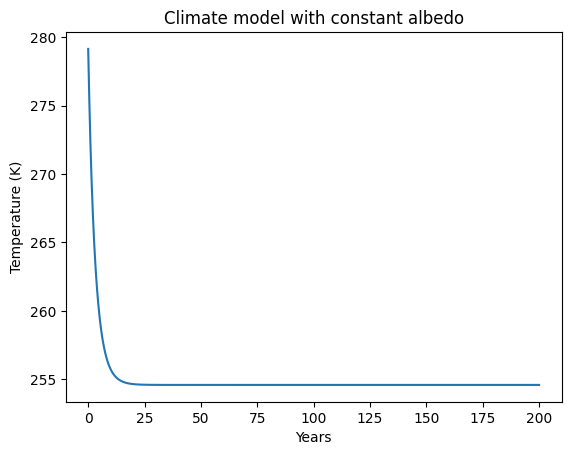

In [25]:
time = np.linspace(0, years, steps)

plt.figure()

plt.plot(time, T_values)

plt.xlabel("Years")
plt.ylabel("Temperature (K)")

plt.title("Climate model with constant albedo")

plt.show()

## Ice-Albedo Feedback

Ice and snow reflect a large fraction of solar radiation.

When the planet cools:

- ice cover increases
- albedo increases
- more sunlight is reflected

This produces additional cooling.

We can represent this feedback by making the albedo depend on temperature

$$
\alpha(T)=0.3 + 0.3*\frac{1-tanh(\frac{T-273}{10})}{2}
$$

In [15]:
def albedo(T):

    return 0.3 + 0.3 * (1 - np.tanh((T - 273)/10)) / 2


In [16]:
def dTdt_feedback(T):

    a = albedo(T)

    incoming = (1 - a) * S / 4

    outgoing = epsilon * sigma * T**4

    return (incoming - outgoing) / C

In [26]:
def rk4_feedback(T,dt):

    k1 = dTdt(T)

    k2 = dTdt(T + 0.5*dt*k1)

    k3 = dTdt(T + 0.5*dt*k2)

    k4 = dTdt(T + dt*k3)

    return T + dt*(k1 + 2*k2 + 2*k3 + k4)/6

In [30]:
T = 280
T = 240

T_values_feedback = []

for i in range(steps):

    T = rk4_feedback(T,dt)

    T_values_feedback.append(T)

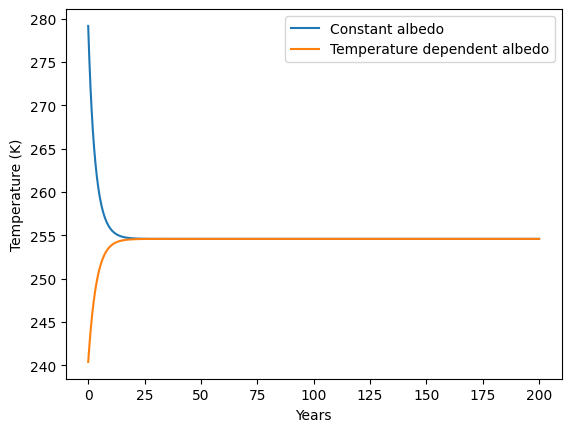

In [31]:
plt.figure()

plt.plot(time,T_values,label="Constant albedo")

plt.plot(time,T_values_feedback,label="Temperature dependent albedo")

plt.xlabel("Years")

plt.ylabel("Temperature (K)")

plt.legend()

plt.show()

## Exploration

Try changing the initial temperature:

- $T_0 = 240K$
- $T_0 = 280K$

Questions:

1. Does the system converge to the same equilibrium temperature?
2. How does the ice-albedo feedback change the evolution?
3. Can the system reach different climate states?

## Climate Stability and Multiple Equilibria

To understand the stability of the climate system, we analyze the **net energy flux** entering the planet:

$$
F(T) = (1-\alpha(T))\frac{S}{4} - \epsilon\sigma T^4
$$

where

- the first term represents **absorbed solar radiation**
- the second term represents **infrared emission to space**

If

$$
F(T) > 0
$$

the planet gains energy and **warms**.

If

$$
F(T) < 0
$$

the planet loses energy and **cools**.

Equilibrium temperatures occur when

$$
F(T) = 0
$$

When the albedo depends on temperature, this equation can have **multiple solutions**, corresponding to different climate states.

These states may represent

- a **warm Earth**
- a **cold glaciated Earth**
- an unstable intermediate state.

This mechanism is related to the **Snowball Earth hypothesis**.

In [32]:
epsilon=0.6

def albedo(T):

    alpha_cold = 0.65
    alpha_warm = 0.25


    T_transition = 273
    width = 5

    return alpha_warm + (alpha_cold - alpha_warm)*(1 - np.tanh((T-T_transition)/width))/2

def energy_flux(T):

    a = albedo(T)

    incoming = (1-a)*S/4

    outgoing = epsilon*sigma*T**4

    return incoming - outgoing

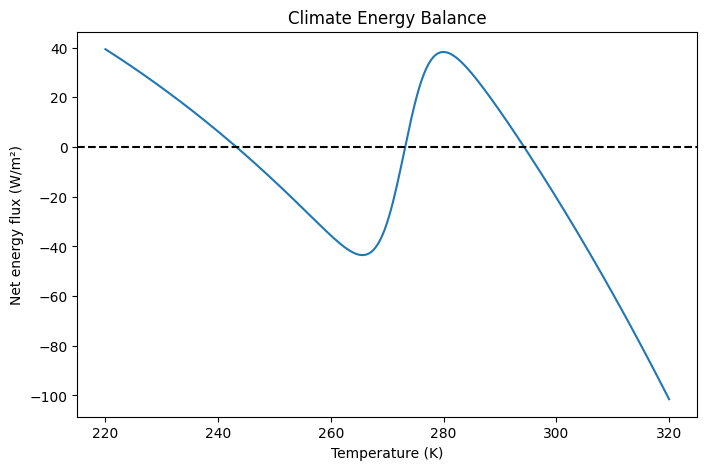

In [33]:
T = np.linspace(220,320,500)

F = energy_flux(T)

plt.figure(figsize=(8,5))

plt.plot(T,F)

plt.axhline(0,color='black',linestyle='--')

plt.xlabel("Temperature (K)")
plt.ylabel("Net energy flux (W/m²)")
plt.title("Climate Energy Balance")

plt.show()

## Interpretation of the Energy Balance Curve

INTERPRETE THE CURVE. AT WHICH TEMPERATURE DO WE HAVE SNOWBALL EARTH, UNSTABLE INTERMEDIATE STATED AND WARM CLIMATE EARTH?

R://

| Temperature | Climate state |
|--------------|---------------|
| 240 K | Snowball Earth |
| 273 K | Unstable intermediate state |
| 295 K | Warm climate similar to modern Earth |

---


